# LDA Implementation from Scratch

Linear Discriminant Analysis using only NumPy and Matplotlib. No built-in LDA implementation is used.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 1. Dataset
Two-class, two-feature example dataset.


In [2]:
X = np.array([
    [4.0, 2.0], [4.5, 2.5], [5.0, 3.0], [5.5, 3.5],
    [8.0, 7.0], [8.5, 7.5], [9.0, 8.0], [9.5, 8.5]
])
y = np.array([0,0,0,0,1,1,1,1])
classes = np.unique(y)
print('Classes:', classes)


Classes: [0 1]


## 2. Overall mean and class-wise means


In [3]:
overall_mean = np.mean(X, axis=0)
class_means = {}
print('Overall mean:', overall_mean)
for cls in classes:
    class_means[cls] = np.mean(X[y == cls], axis=0)
    print(f'Class {cls} mean:', class_means[cls])


Overall mean: [6.75 5.25]
Class 0 mean: [4.75 2.75]
Class 1 mean: [8.75 7.75]


## 3. Within-Class Scatter Matrix (SW)
SW measures variation within each class. LDA prefers directions with low within-class scatter.


In [4]:
SW = np.zeros((X.shape[1], X.shape[1]))
for cls in classes:
    X_class = X[y == cls]
    centered = X_class - class_means[cls]
    SW += centered.T @ centered
print('SW =')
print(SW)


SW =
[[2.5 2.5]
 [2.5 2.5]]


## 4. Between-Class Scatter Matrix (SB)
SB measures how far class means are from the overall mean. LDA prefers directions with high between-class scatter.


In [5]:
SB = np.zeros((X.shape[1], X.shape[1]))
for cls in classes:
    X_class = X[y == cls]
    n_class = X_class.shape[0]
    d = (class_means[cls] - overall_mean).reshape(-1,1)
    SB += n_class * (d @ d.T)
print('SB =')
print(SB)


SB =
[[32. 40.]
 [40. 50.]]


## 5. Eigenvalue problem
LDA solves SB w = lambda SW w, equivalently SW^-1 SB w = lambda w when SW is invertible. Eigenvectors are discriminant directions and larger eigenvalues indicate stronger separation.


In [8]:
# Check whether SW is singular
if np.linalg.matrix_rank(SW) < SW.shape[0]:
    print("SW is singular. Using pseudo-inverse instead of inverse.")

    # Moore-Penrose pseudo-inverse
    SW_inv = np.linalg.pinv(SW)
else:
    # Normal inverse
    SW_inv = np.linalg.inv(SW)

# Calculate SW^-1 SB
M = SW_inv @ SB

# Calculate eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(M)

# Remove tiny numerical imaginary parts
eigvals = np.real(eigvals)
eigvecs = np.real(eigvecs)

print("SW^-1 SB =")
print(M)

print("\nEigenvalues:")
print(eigvals)

print("\nEigenvectors:")
print(eigvecs)


SW is singular. Using pseudo-inverse instead of inverse.
SW^-1 SB =
[[7.2 9. ]
 [7.2 9. ]]

Eigenvalues:
[ 0.  16.2]

Eigenvectors:
[[-0.78086881 -0.70710678]
 [ 0.62469505 -0.70710678]]


## 6. Sort eigenvectors and select top k
For C classes, at most C-1 LDA components can be selected.


In [9]:
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
k = min(len(classes)-1, X.shape[1])
W = eigvecs[:, :k]
print('Sorted eigenvalues:', eigvals)
print('Selected W:\n', W)


Sorted eigenvalues: [16.2  0. ]
Selected W:
 [[-0.70710678]
 [-0.70710678]]


## 7. Project the data
The reduced feature matrix is X_LDA = (X - overall_mean)W.


In [10]:
X_centered = X - overall_mean
X_lda = X_centered @ W
print('Reduced-dimensional feature matrix:')
print(X_lda)
print('Original shape:', X.shape)
print('LDA shape:', X_lda.shape)


Reduced-dimensional feature matrix:
[[ 4.24264069]
 [ 3.53553391]
 [ 2.82842712]
 [ 2.12132034]
 [-2.12132034]
 [-2.82842712]
 [-3.53553391]
 [-4.24264069]]
Original shape: (8, 2)
LDA shape: (8, 1)


## 8. Visualization
For two classes, the maximum number of discriminant components is one, so the projected samples are plotted along LD1.


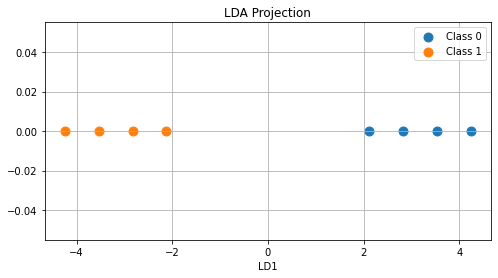

In [11]:
plt.figure(figsize=(8,4))
for cls in classes:
    points = X_lda[y == cls, 0]
    plt.scatter(points, np.zeros_like(points), s=80, label=f'Class {cls}')
plt.xlabel('LD1')
plt.title('LDA Projection')
plt.legend()
plt.grid(True)
plt.show()


## Conclusion
LDA maximizes class separability by finding directions that increase between-class scatter while reducing within-class scatter. The selected eigenvectors form the new discriminant subspace, and the largest eigenvalues identify the most useful directions.